In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Pulling Data
df = pd.read_csv(r"https://github.com/qui-ce-moi/Culinary-Data-Analysis-with-Logistic-Model/blob/main/recipe_site_traffic_2212.csv")
df.head()

HTTPError: HTTP Error 429: Too Many Requests

In [ ]:
#Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB


In [ ]:
#Data Description
df.describe()

,recipe,calories,carbohydrate,sugar,protein
count,947.000000,895.000000,895.000000,895.000000,895.000000
mean,474.000000,435.939196,35.069676,9.046547,24.149296
std,273.519652,453.020997,43.949032,14.679176,36.369739
min,1.000000,0.140000,0.030000,0.010000,0.000000
25%,237.500000,110.430000,8.375000,1.690000,3.195000
50%,474.000000,288.550000,21.480000,4.550000,10.800000
75%,710.500000,597.650000,44.965000,9.800000,30.200000
max,947.000000,3633.160000,530.420000,148.750000,363.360000


In [ ]:
#Category Count
df["category"].value_counts()

category
Breakfast         106
Chicken Breast     98
Beverages          92
Lunch/Snacks       89
Potato             88
Pork               84
Vegetable          83
Dessert            83
Meat               79
Chicken            74
One Dish Meal      71
Name: count, dtype: int64

In [ ]:
#Servings Count
df["servings"].value_counts()

servings
4               389
6               197
2               183
1               175
4 as a snack      2
6 as a snack      1
Name: count, dtype: int64

In [ ]:
#Deleting str from servings column
df["servings"] = df["servings"].str.replace(" as a snack", "")
df["servings"] = df["servings"].astype(int)

In [ ]:
#Finding the number of people each dish serves
df["servings"].value_counts()

servings
4    391
6    198
2    183
1    175
Name: count, dtype: int64

In [ ]:
#Make high traffic 1 and others 0
df["high_traffic"] = df["high_traffic"].map({"High": 1})
df["high_traffic"].fillna(0, inplace=True)

C:\Users\emirc\AppData\Local\Temp\ipykernel_17544\3451023494.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["high_traffic"].fillna(0, inplace=True)


In [ ]:
#High traffic count
df["high_traffic"].value_counts()

high_traffic
1.0    574
0.0    373
Name: count, dtype: int64

In [ ]:
# Chicken Breast -> Chicken
df["category"] = df["category"].replace("Chicken Breast", "Chicken")
df["category"].value_counts()

category
Chicken          172
Breakfast        106
Beverages         92
Lunch/Snacks      89
Potato            88
Pork              84
Dessert           83
Vegetable         83
Meat              79
One Dish Meal     71
Name: count, dtype: int64

In [ ]:
#Nutritional values (calories, carbohydrate, sugar, protein) missing values management
#To prevent data loss, I filled the missing values with the median value of each category.
nutritional_cols = ['calories', 'carbohydrate', 'sugar', 'protein']
for col in nutritional_cols:
    df[col] = df.groupby('category')[col].transform(lambda x: x.fillna(x.median()))

In [ ]:
#Checking the results
print("--- CLEANED DATA SUMMARY ---")
print(f"Total Rows: {len(df)}")
print("\nNumber of Missing Values:")
print(df.isnull().sum())
print("\nCategory Distribution:")
print(df['category'].value_counts())
print("\nServings Unique Values:")
print(df['servings'].unique())
print("\nHigh Traffic Distribution:")
print(df['high_traffic'].value_counts())

--- TEMİZLİK SONRASI VERİ ÖZETİ ---
Toplam Satır: 947

Eksik Değer Sayısı:
recipe          0
calories        0
carbohydrate    0
sugar           0
protein         0
category        0
servings        0
high_traffic    0
dtype: int64

Kategori Dağılımı:
category
Chicken          172
Breakfast        106
Beverages         92
Lunch/Snacks      89
Potato            88
Pork              84
Dessert           83
Vegetable         83
Meat              79
One Dish Meal     71
Name: count, dtype: int64

Servings Benzersiz Değerler:
[6 4 1 2]

High Traffic Dağılımı:
high_traffic
1.0    574
0.0    373
Name: count, dtype: int64


In [ ]:
#Set theme
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [5, 3]

C:\Users\emirc\AppData\Local\Temp\ipykernel_17544\1528339708.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='high_traffic', palette='viridis')


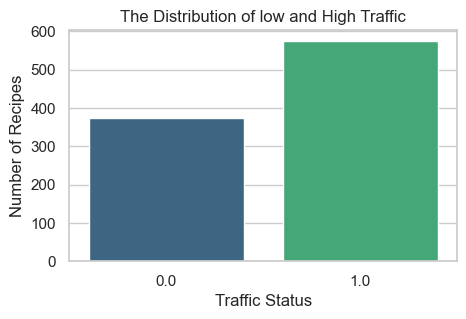

In [ ]:
#The Distribution of low and High Traffic
plt.figure()
sns.countplot(data=df, x='high_traffic', palette='viridis')
plt.title('The Distribution of low and High Traffic')
plt.xlabel('Traffic Status')
plt.ylabel('Number of Recipes')
plt.show()

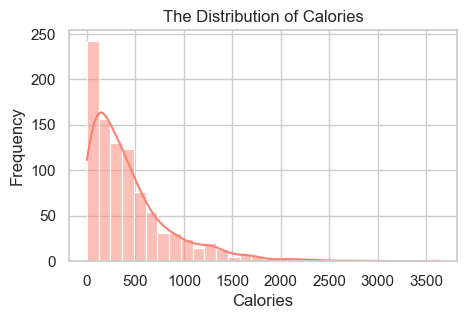

In [ ]:
#The Distribution of Calories
plt.figure()
sns.histplot(data=df, x='calories', bins=30, kde=True, color='salmon')
plt.title('The Distribution of Calories')
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.show()

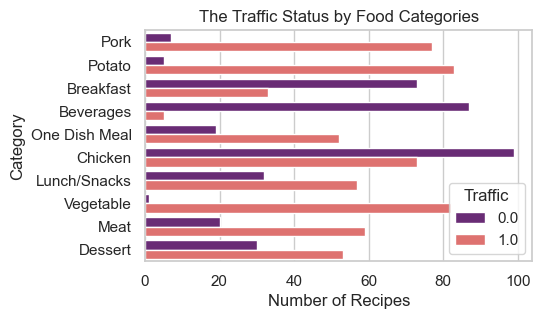

In [ ]:
#The Traffic Status by Food Categories
plt.figure()
sns.countplot(data=df, y='category', hue='high_traffic', palette='magma')
plt.title('The Traffic Status by Food Categories')
plt.xlabel('Number of Recipes')
plt.ylabel('Category')
plt.legend(title='Traffic', loc='lower right')
plt.show()

C:\Users\emirc\AppData\Local\Temp\ipykernel_17544\1212144857.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', palette='viridis', order=df['category'].value_counts().index)


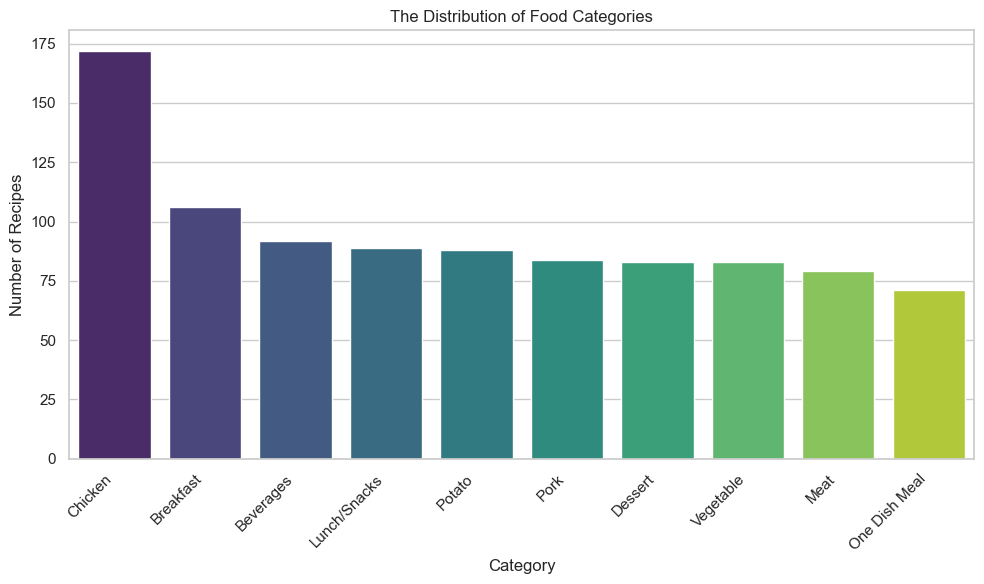

In [ ]:
#The Distribution of Food Categories
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='category', palette='viridis', order=df['category'].value_counts().index)
plt.title('The Distribution of Food Categories')
plt.xlabel('Category')
plt.ylabel('Number of Recipes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Axes: xlabel='servings', ylabel='Count'>

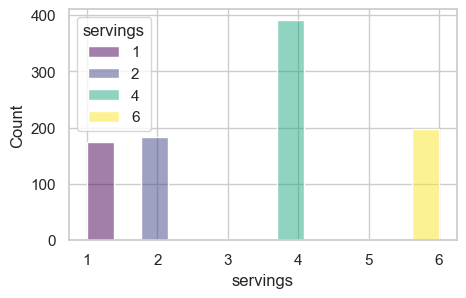

In [ ]:
#The Distribution of Servings
sns.histplot(data=df, x="servings", hue = "servings" ,palette = "viridis")

In [ ]:
#Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Making target variable numeric (High=1, Low=0)
le = LabelEncoder()
df['high_traffic_binary'] = le.fit_transform(df['high_traffic'])

# Categorical columns (category) 'One-Hot Encoding' with numeric
df_model = pd.get_dummies(df, columns=['category'], drop_first=True)

# Features (X) and Target (y) defining
# 'recipe' (id) and 'high_traffic' (text) columns are removed
X = df_model.drop(['recipe', 'high_traffic', 'high_traffic_binary'], axis=1)
y = df_model['high_traffic_binary']

# Splitting data into 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling numerical data (Especially important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Making the model
baseline_model = LogisticRegression()
baseline_model.fit(X_train_scaled, y_train)

# Making the prediction
y_pred_baseline = baseline_model.predict(X_test_scaled)

print("--- Baseline Model (Logistic Regression) Report ---")
print(classification_report(y_test, y_pred_baseline))

--- Baseline Model (Logistic Regression) Report ---
              precision    recall  f1-score   support

           0       0.69      0.79      0.74        75
           1       0.85      0.77      0.81       115

    accuracy                           0.78       190
   macro avg       0.77      0.78      0.77       190
weighted avg       0.79      0.78      0.78       190



In [ ]:
# Making the model
comparison_model = RandomForestClassifier(n_estimators=100, random_state=42)
comparison_model.fit(X_train, y_train) # Scaling is not mandatory for tree-based models

# Making the prediction
y_pred_comparison = comparison_model.predict(X_test)

print("--- Comparison Model (Random Forest) Report ---")
print(classification_report(y_test, y_pred_comparison))

--- Comparison Model (Random Forest) Report ---
              precision    recall  f1-score   support

           0       0.61      0.72      0.66        75
           1       0.79      0.70      0.75       115

    accuracy                           0.71       190
   macro avg       0.70      0.71      0.70       190
weighted avg       0.72      0.71      0.71       190



True Negative (Doğru Düşük): 59
False Positive (Hatalı Yüksek): 16
False Negative (Hatalı Düşük): 26
True Positive (Doğru Yüksek): 89


<Figure size 800x600 with 0 Axes>

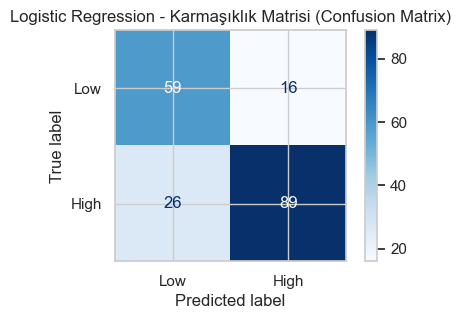

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Data
df = pd.read_csv('recipe_site_traffic_2212.csv')

# 2. Data Cleaning
# Making servings numeric
df['servings'] = df['servings'].astype(str).str.replace(' as a snack', '', regex=False).astype(int)

# Making category numeric
df['category'] = df['category'].replace('Chicken Breast', 'Chicken')

# Making target variable numeric (High=1, Low=0)
df['high_traffic'] = df['high_traffic'].fillna('Low')
df['target'] = df['high_traffic'].apply(lambda x: 1 if x == 'High' else 0)

# Filling missing nutritional values with category median
nutritional_cols = ['calories', 'carbohydrate', 'sugar', 'protein']
for col in nutritional_cols:
    df[col] = df.groupby('category')[col].transform(lambda x: x.fillna(x.median()))

# 3. Model Preparation
X = pd.get_dummies(df.drop(['recipe', 'high_traffic', 'target'], axis=1), columns=['category'], drop_first=True)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Logistic Regression Training
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression - Confusion Matrix')
plt.savefig('logistic_confusion_matrix.png')

tn, fp, fn, tp = cm.ravel()
print(f"True Negative (Correct Low): {tn}")
print(f"False Positive (Incorrect High): {fp}")
print(f"False Negative (Incorrect Low): {fn}")
print(f"True Positive (Correct High): {tp}")